Experiment 4: Convolutional Neural Networks

Aim: To implement Convolutional Neural Networks using TensorFlow and Keras for image classification.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 244s 1us/step


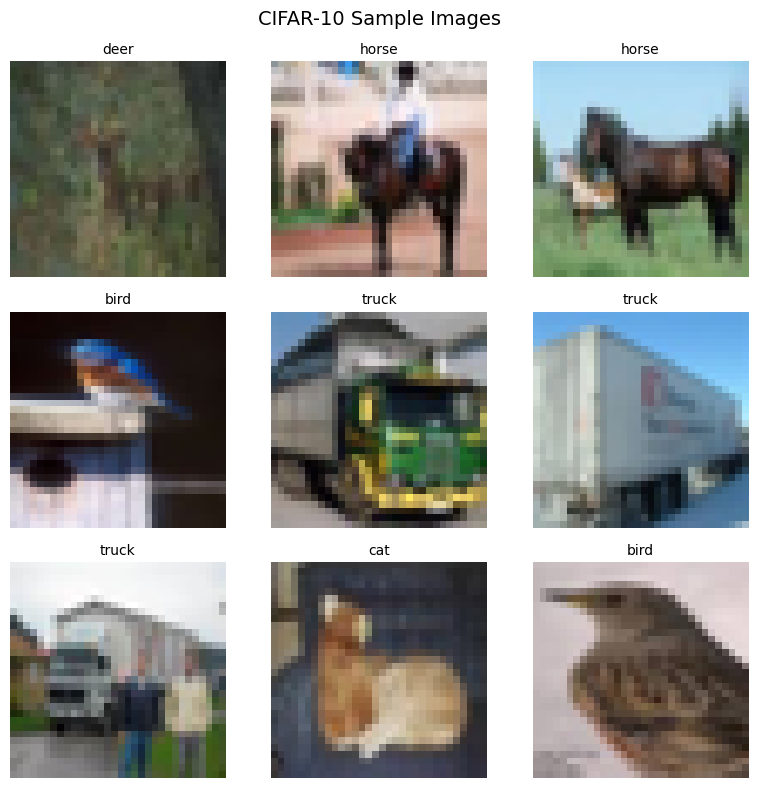

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 149s 187ms/step - accuracy: 0.3516 - loss: 1.7669 - val_accuracy: 0.5179 - val_loss: 1.3505
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 180ms/step - accuracy: 0.4839 - loss: 1.4329 - val_accuracy: 0.5672 - val_loss: 1.2213
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 178ms/step - accuracy: 0.5394 - loss: 1.2945 - val_accuracy: 0.6043 - val_loss: 1.1166
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 183ms/step - accuracy: 0.5780 - loss: 1.1915 - val_accuracy: 0.6406 - val_loss: 1.0269
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 181ms/step - accuracy: 0.6108 - loss: 1.1120 - val_accuracy: 0.6721 - val_loss: 0.9621
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 180ms/step - accuracy: 0.6347 - loss: 1.0430 - val_accuracy: 0.6878 - val_loss: 0.8923
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 179ms/step - accuracy: 0.6577 - loss: 0.9761 - val_accuracy: 0.7078 - val_loss: 0.8343
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 184ms/step - accuracy: 0.6777 -

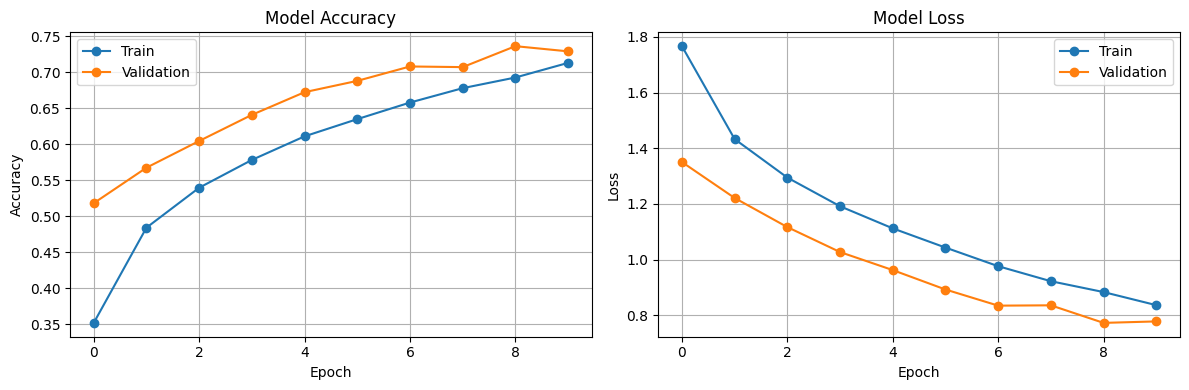

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class Labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display Sample Images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('CIFAR-10 Sample Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i + 10])                      # Start from index 10
    ax.set_title(class_names[y_train[i + 10][0]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Build CNN Model
model = models.Sequential([

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),  # 128 filters instead of 64

    # Flatten + Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),               # 128 units instead of 64
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # Custom learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,                                      # Explicit batch size
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# Plot Accuracy & Loss Graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation', marker='o')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train', marker='o')
ax2.plot(history.history['val_loss'], label='Validation', marker='o')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Conclusion: Successfully implemented Convolutional Neural Network using Keras and TensorFlow for image classification on the CIFAR-10 dataset.

